In [60]:
#Importando bibliotecas utilizadas ao longo do projeto

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
#Carregando o dataset via google drive

from google.colab import drive
drive.mount('/content/drive')


caminho_csv = '/content/drive/MyDrive/portfolio_spotify_tracks.py/spotify-tracks-dataset.csv'
df = pd.read_csv(caminho_csv, encoding='utf-8')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Antes de responder as questões, faremos uma análise exploratória e tratamento dos dados, se necessário

In [62]:
#Consultando as cinco primeiras linhas do dataset

df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Como podemos ver acima, temos duas colunas com índice.


Iremos tratar a seguir:

In [63]:
#Usando a função drop do pandas para remover as duas colunas

df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

In [64]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [65]:
#Consultando a estrutura, tipos das colunas e valores nulos do DF.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

Encontramos três colunas com valores nulos (artists, album_name e track_name) iremos excluir os valores nulos:

In [66]:
#Consultando linha com valores nulos pela coluna "artists"

df[df['artists'].isna()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


A mesma linha representa os valores nulos das três colunas, logo apenas precisamos dropar ela do nosso DataFrame:

In [67]:
df = df.dropna(subset=['artists'])

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  bool   
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           113999 

In [69]:
#Consultando estatísticas descritivas de todas as colunas numéricas.

df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [70]:
#Consultando estatísticas descritivas de todas as colunas categóricas.

df.describe(include='object')

,track_id,artists,album_name,track_name,track_genre
count,113999,113999,113999,113999,113999
unique,89740,31437,46589,73608,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,9,279,195,151,1000


In [71]:
#Consultando linhas duplicadas

df.duplicated().sum()

np.int64(450)

In [72]:
#Removendo linhas duplicadas usando a track_id

df.drop_duplicates(subset=['track_id'], inplace=True)

In [73]:
#Consultando linhas duplicadas novamente

df.duplicated().sum()

np.int64(0)

#1 - Popularidade

- Quais são as músicas mais populares do dataset?

- Qual é a média de popularidade das faixas?

- Quais álbuns têm maior média de popularidade?

### 1.1 - Quais são as músicas mais populares do dataset?


In [74]:
#Criando variável ordenando valores pela coluna de popularidade
musicas_populares = df.sort_values(by= 'popularity', ascending=False)

In [75]:
#Apresentando top 10:

musicas_populares.head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance
51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop
20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,dance
67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latin
67358,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,1,-5.105,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,latin
67359,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,False,0.650,0.715,5,-5.198,0,0.2530,0.09930,0.000291,0.1260,0.187,106.672,4,latin
79000,4h9wh7iOZ0GGn8QVp4RAOB,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,I Ain't Worried,96,148485,False,0.704,0.797,0,-5.927,1,0.0475,0.08260,0.000745,0.0546,0.825,139.994,4,piano
20000,5IgjP7X4th6nMNDh4akUHb,Chris Brown,Indigo (Extended),Under The Influence,96,184613,True,0.733,0.690,9,-5.529,0,0.0427,0.06350,0.000001,0.1050,0.310,116.992,4,dance
67559,5Eax0qFko2dh7Rl2lYs3bx,Bad Bunny,Un Verano Sin Ti,Efecto,96,213061,False,0.801,0.475,7,-8.797,0,0.0516,0.14100,0.000017,0.0639,0.234,98.047,4,latin
81052,4LRPiXqCikLlN15c3yImP7,Harry Styles,As It Was,As It Was,95,167303,False,0.520,0.731,6,-5.338,0,0.0557,0.34200,0.001010,0.3110,0.662,173.930,4,pop


Descrição da variável "popularity":

Um valor entre 0 e 100 que indica a popularidade da música. Quanto maior o valor, mais popular ela é. Baseia-se principalmente na quantidade de reproduções e na data dessas reproduções.


###1.2 - Qual é a média de popularidade das faixas?

In [76]:
#1.2 - Qual é a média de popularidade das faixas?

media_popularity = df['popularity'].mean()

print(f'A media de popularidade é: {media_popularity:.2f}')

A media de popularidade é: 33.20


### 1.3 - Quais álbuns têm maior média de popularidade?


In [77]:
#1.3 - Quais álbuns têm maior média de popularidade?

#Criando chave para evitar misturar a média dos artistas, pois podem existir álbuns com o mesmo nome

min_album = ['artists', 'album_name'] if 'artists' in df else ['album_name']


In [78]:
#Criando variável com mínimo de músicas, evitando "singles"

min_track = 5

In [79]:
#Calculando média dos álbuns utilizando groupby

media_album = (
    df.groupby(min_album, as_index=False)
      .agg(qtd_faixas=('popularity', 'size'),
           media_pop=('popularity', 'mean'))
)

media_album = media_album[media_album['qtd_faixas'] >= min_track]

In [80]:
#Criando variável de top 10 álbuns com maior média de popularidade

top_albuns = media_album.sort_values('media_pop', ascending=False).head(10)

print('O top 10 álbuns mais populares é:')
top_albuns

O top 10 álbuns mais populares é:


,artists,album_name,qtd_faixas,media_pop
5519,Bad Bunny,Un Verano Sin Ti,13,88.076923
40875,Olivia Rodrigo,SOUR,5,87.400000
5522,Bad Bunny,YHLQMDLG,5,80.600000
6964,Billie Eilish,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",5,78.000000
4054,Arctic Monkeys,AM,12,77.333333
59860,XXXTENTACION,17,7,76.285714
6966,Billie Eilish,dont smile at me,6,76.166667
36463,Melanie Martinez,Cry Baby (Deluxe Edition),6,76.166667
6956,Billie Eilish,Happier Than Ever,9,76.111111
590,AC/DC,Back In Black,5,75.400000


#2 - Duração e estrutura das músicas

- Qual é a duração média das faixas?
- Existem músicas extremamente longas ou curtas (outliers)?
- Qual é a faixa de duração mais comum?
- Quais são os gêneros com músicas mais longas?

###2.1 - Qual é a duração média das faixas?


In [81]:
#Convertendo a média de milisegundos para segundos, e depois para minutos

media_min = df['duration_ms'].mean() / 1000 / 60

#Criando variável de minutos e segundos

duracao_media_min = int(media_min)

duracao_media_sec = (media_min - duracao_media_min) * 60

In [82]:
print(f'A média de duração das faixas é de: {duracao_media_min} minutos e {duracao_media_sec:.0f} segundos')

A média de duração das faixas é de: 3 minutos e 49 segundos


In [83]:
duracao_mediana_min = df['duration_ms'].median() / 1000 / 60
print(f'A mediana do tempo de duração das faixas é de: {duracao_mediana_min:.2f} minutos') #Mediana é o valor central dos dados

A mediana do tempo de duração das faixas é de: 3.55 minutos


###2.2 - Existem músicas extremamente longas ou curtas (outliers)?

Para a próxima questão, utilizaremos a abordagem de percentis para calcular os outliers, porém existem diversas outras formas de encontrarmos.

Escolhi utilizar P1 como mínimo e P99 como máximo

In [84]:
minutos = (df['duration_ms'] / 60000)

#Usando percentis para encontrar outliers

#Neste caso estou usando função .quantile para calcular o percentil 1 (o que estiver abaixo desse valor é um outlier negativo) e percentil 99 (o que estiver acima desse valor é um outlier positivo)

p1  = minutos.quantile(0.01)
p99 = minutos.quantile(0.99)

print(f'Percentil 1:  {p1:.2f} minutos')
print(f'Percentil 99): {p99:.2f} minutos')

Percentil 1:  1.03 minutos
Percentil 99): 9.10 minutos


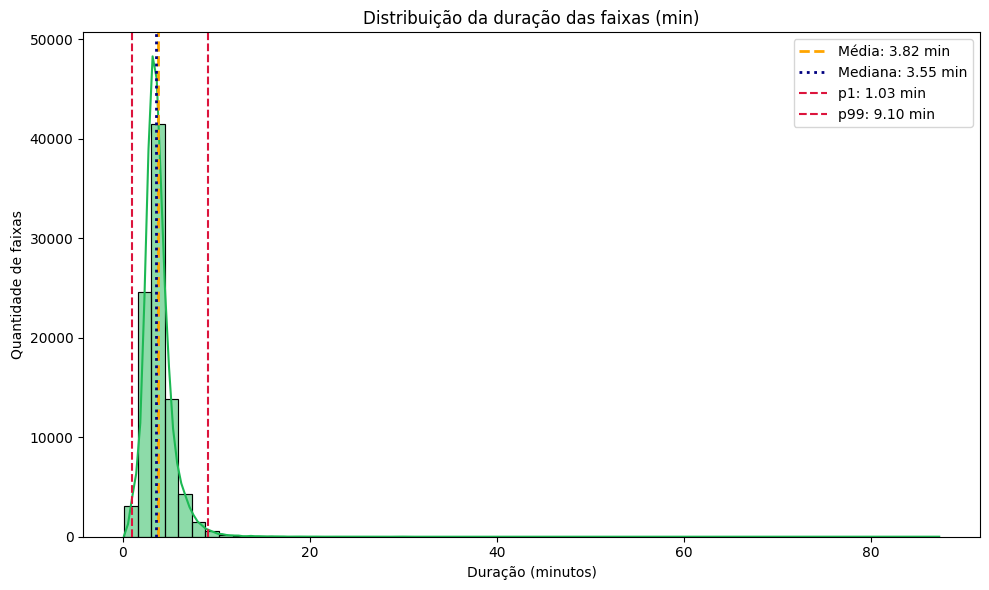

In [85]:
#Histograma da distribuição + linhas (média/mediana) + limites (p1/p99)

plt.figure(figsize=(10, 6))
sns.histplot(minutos, bins=60, color='#1DB954', kde=True)

plt.axvline(media_min,   color='orange', linestyle='--', linewidth=2, label=f'Média: {media_min:.2f} min')
plt.axvline(duracao_mediana_min, color='navy',    linestyle=':',  linewidth=2, label=f'Mediana: {duracao_mediana_min:.2f} min')
plt.axvline(p1,          color='crimson',  linestyle='--', linewidth=1.5, label=f'p1: {p1:.2f} min')
plt.axvline(p99,         color='crimson',  linestyle='--', linewidth=1.5, label=f'p99: {p99:.2f} min')

plt.xlabel('Duração (minutos)')
plt.ylabel('Quantidade de faixas')
plt.title('Distribuição da duração das faixas (min)')
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
print(f'Valor mínimo de duração: {minutos.min():.2f} minutos')
print(f'Faixas com duração abaixo de 1 minuto: {(minutos < 1).sum()} faixas')
print(f'Faixas com duração abaixo de 30 segundos: {(minutos < 0.5).sum()} faixas')

Valor mínimo de duração: 0.14 minutos
Faixas com duração abaixo de 1 minuto: 771 faixas
Faixas com duração abaixo de 30 segundos: 14 faixas


In [87]:
min_duracao = df['duration_ms'].idxmin()
linha_min = df.loc[min_duracao]
print(linha_min)

track_id            6hsyfegVY5yklJneM40mWi
artists                         Leila Bela
album_name                     Angra Manyu
track_name          The Exorsism Begins...
popularity                               0
duration_ms                           8586
explicit                             False
danceability                           0.0
energy                                0.04
key                                      8
loudness                           -29.714
mode                                     0
speechiness                            0.0
acousticness                         0.928
instrumentalness                     0.956
liveness                             0.115
valence                                0.0
tempo                                  0.0
time_signature                           0
track_genre                        iranian
Name: 59310, dtype: object


In [88]:
print(f'Valor máximo de duração: {minutos.max():.2f} minutos')

print(f'Faixas com duração acima de 20 minutos: {(minutos > 20).sum()} faixas')

print(f'Faixas com duração acima de 60 minutos: {(minutos > 60).sum()} faixas')

Valor máximo de duração: 87.29 minutos
Faixas com duração acima de 20 minutos: 73 faixas
Faixas com duração acima de 60 minutos: 15 faixas


In [89]:
max_duracao = df['duration_ms'].idxmax()
linha_max = df.loc[max_duracao]
print(linha_max)

track_id              3Cnz3Bu9Wcw8p3kiBTXTxp
artists                           Tale Of Us
album_name                Unity (Voyage Mix)
track_name          Unity (Voyage Mix) Pt. 1
popularity                                35
duration_ms                          5237295
explicit                               False
danceability                           0.695
energy                                 0.736
key                                        5
loudness                             -11.371
mode                                       0
speechiness                           0.0374
acousticness                         0.00399
instrumentalness                        0.86
liveness                               0.091
valence                               0.0509
tempo                                124.001
time_signature                             4
track_genre                   minimal-techno
Name: 73617, dtype: object


### 2.3 - Qual é a faixa de duração mais comum?

In [90]:
#Utilizando a função .mode para extrair a moda da coluna de duração

moda = df['duration_ms'].mode().iloc[0]

moda_min = moda / 1000 / 60

In [91]:
print(f'A duração mais comum das faixas é de: {moda_min} minutos')

A duração mais comum das faixas é de: 3.0 minutos


### 2.4 - Quais são os gêneros com músicas mais longas?

In [101]:
musicas_longas = (
    df.groupby('track_genre')['duration_ms']
      .mean()
      .div(60000)  #Convertendo ms para minutos
      .sort_values(ascending=False)
      .rename('duration_min')
)

top10_musicas_longas = musicas_longas.reset_index()

top10_musicas_longas.head(10)

,track_genre,duration_min
0,detroit-techno,6.212381
1,minimal-techno,6.187208
2,chicago-house,6.114782
3,iranian,5.326178
4,techno,5.314420
5,breakbeat,5.290067
6,black-metal,5.181732
7,gospel,5.032477
8,new-age,4.987297
9,world-music,4.897511
